In [ ]:
%%capture
!pip install koreanize-matplotlib
import koreanize_matplotlib

In [ ]:
selected_features = [
    '한국 외환 보유액', '한국 상품수지', '외국인 투자 금액', '경제 심리 지수',
    'WTI 유가', '두바이 유가', 'Brent 유가', '천연가스 가격', '유연탄 가격',
    '구리 가격', '알루미늄 가격', '니켈 가격', '아연 가격', '대두 가격',
    '옥수수 가격', '소맥 가격', '원당 가격', '원면 가격',
    '미국 주가지수', '한국 주가지수',
    '미국 기준 금리', '한국 기준 금리',
    '한국 10년 채권수익률', '실질GDP성장률'
]

<ipython-input-4-00cadfe2d2fb>:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')


✅ 데이터 준비 완료! X_scaled shape: (300, 24)
✅ 클러스터링 완료! 클러스터 분포:
Cluster
1    203
0     97
Name: count, dtype: int64


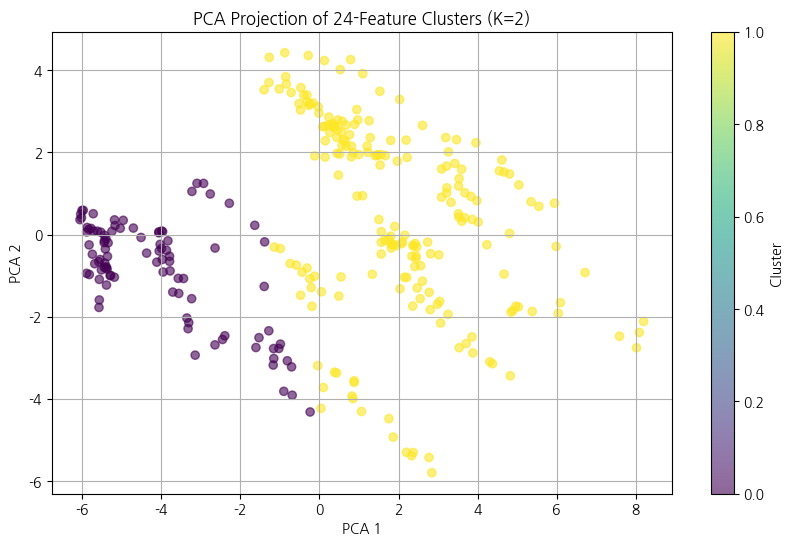

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('/content/exchange_final.csv')  # 경로는 상황에 맞게 수정

# 2. 24개 Feature만 선택
X = df[selected_features].copy()

# 3. 결측치 처리 (보간 + 앞뒤 채움)
X = X.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')

# 4. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ 데이터 준비 완료! X_scaled shape: {X_scaled.shape}")

# 5. KMeans 클러스터링 (k=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_scaled)

# 클러스터 결과를 데이터프레임에 추가
df['Cluster'] = clusters

print(f"✅ 클러스터링 완료! 클러스터 분포:")
print(df['Cluster'].value_counts())

# 6. 클러스터 결과 시각화 (PCA로 2D 변환해서 볼 수도 있어)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', alpha=0.6)
plt.title('PCA Projection of 24-Feature Clusters (K=2)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)
plt.colorbar(label='Cluster')
plt.show()


## 클러스터별 원/달러 환율 평균 비교

✅ 클러스터별 원/달러환율 평균:
 Cluster
0    1152.707835
1    1152.303498
Name: 원/달러환율, dtype: float64


<ipython-input-5-fffc08c07a8d>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='원/달러환율', data=df, palette='Set2')


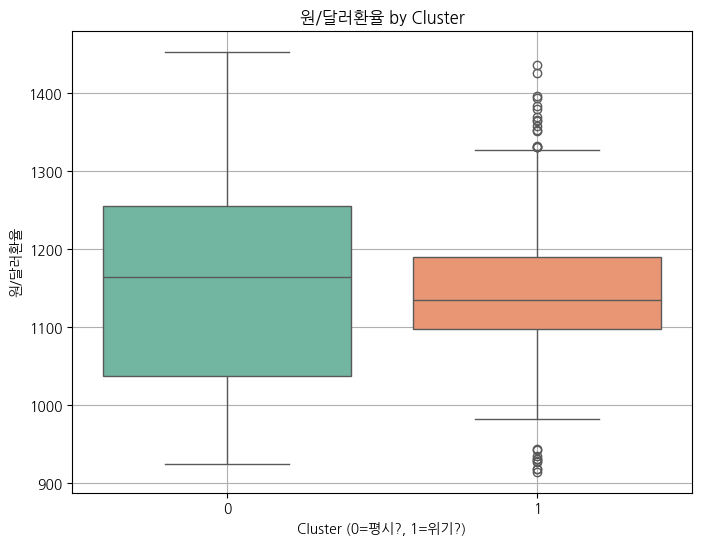

In [ ]:
# 1. 환율 컬럼 추가해서 클러스터별 평균 비교
df['원/달러환율']  # (원래 exchange_final.csv에 들어있음)

# 2. 클러스터별 원/달러환율 평균 계산
mean_rates = df.groupby('Cluster')['원/달러환율'].mean()
print("✅ 클러스터별 원/달러환율 평균:\n", mean_rates)

# 3. 박스플롯으로 시각화
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(x='Cluster', y='원/달러환율', data=df, palette='Set2')
plt.title('원/달러환율 by Cluster')
plt.xlabel('Cluster (0=평시?, 1=위기?)')
plt.ylabel('원/달러환율')
plt.grid(True)
plt.show()


클러스터별 원/달러환율 변동성(std) 비교

변동성은
➔ "평소에 얼마나 시장이 흔들거리는가?"
➔ 장기적이고 전체적인 "흔들림의 크기"를 보는 것.

In [ ]:
# 1. 클러스터별 환율 표준편차(변동성) 비교
volatility = df.groupby('Cluster')['원/달러환율'].std()
print("✅ 클러스터별 환율 변동성 (표준편차):\n", volatility)

✅ 클러스터별 환율 변동성 (표준편차):
 Cluster
0    133.270401
1    103.143831
Name: 원/달러환율, dtype: float64


클러스터별 환율 급등/급락 분석

급등락은
➔ "지금 이 순간 얼마나 크게 튀었는가?"
➔ 특정 순간순간의 "급격한 이벤트"를 보는 것.

✅ 클러스터별 평균 환율 변화폭:
 Cluster
0    20.580312
1    17.646552
Name: abs_diff, dtype: float64


<ipython-input-7-17f25434105a>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='abs_diff', data=df, palette='Set2')


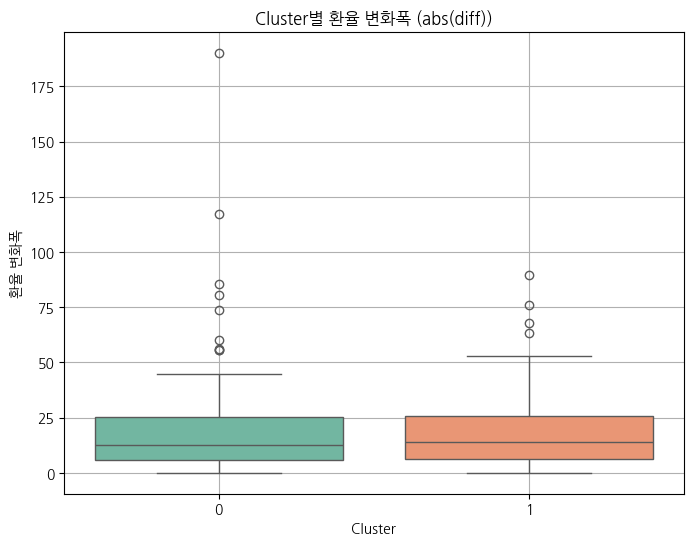

In [ ]:
# 2. 환율의 변화량(diff) 계산
df['환율변화량'] = df['원/달러환율'].diff()

# 3. 클러스터별 변화량의 절댓값 평균 계산
df['abs_diff'] = df['환율변화량'].abs()
avg_abs_diff = df.groupby('Cluster')['abs_diff'].mean()
print("✅ 클러스터별 평균 환율 변화폭:\n", avg_abs_diff)

# 4. 클러스터별 변화량 Boxplot 그리기
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(x='Cluster', y='abs_diff', data=df, palette='Set2')
plt.title('Cluster별 환율 변화폭 (abs(diff))')
plt.xlabel('Cluster')
plt.ylabel('환율 변화폭')
plt.grid(True)
plt.show()


<Figure size 1400x700 with 0 Axes>

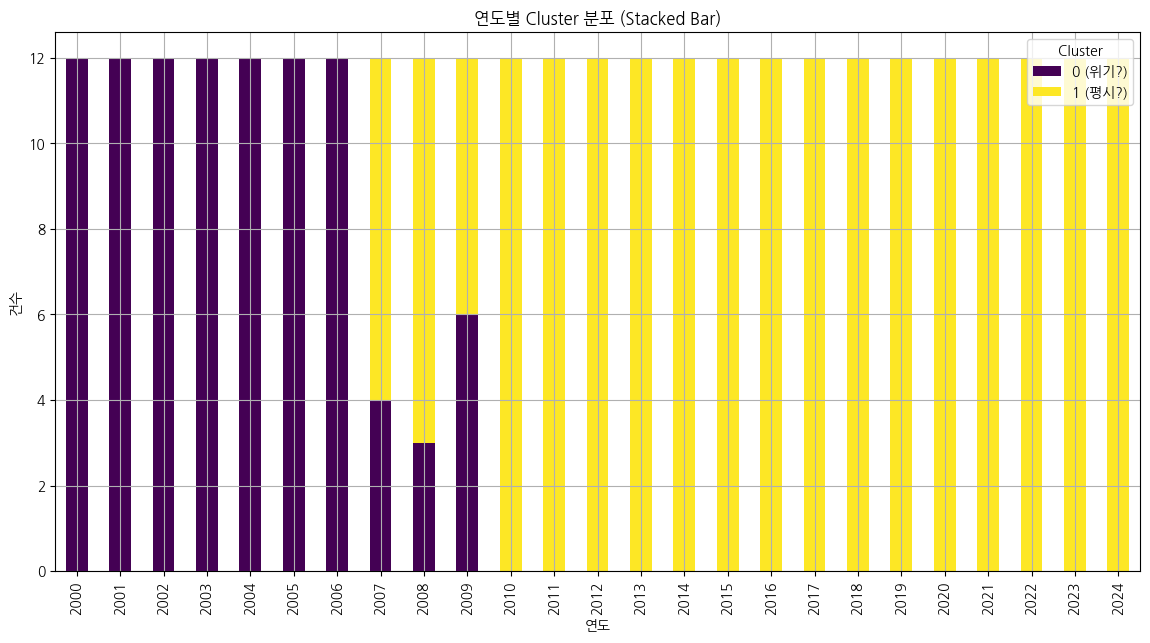

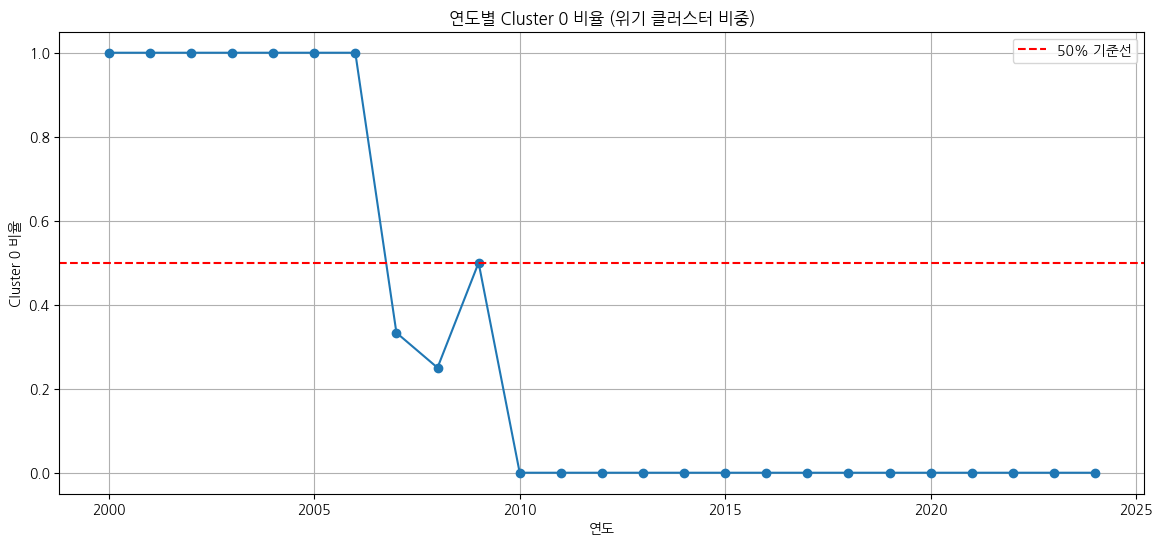

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 연도 추출
df['연도'] = pd.to_datetime(df['TIME']).dt.year  # 'TIME' 컬럼이 날짜형식이라고 가정

# 2. 연도별 클러스터 분포 집계
cluster_counts = df.groupby(['연도', 'Cluster']).size().unstack(fill_value=0)

# 3. 그래프로 시각화
plt.figure(figsize=(14,7))
cluster_counts.plot(kind='bar', stacked=True, colormap='viridis', figsize=(14,7))
plt.title('연도별 Cluster 분포 (Stacked Bar)')
plt.xlabel('연도')
plt.ylabel('건수')
plt.legend(title='Cluster', labels=['0 (위기?)', '1 (평시?)'])
plt.grid(True)
plt.show()

# 4. Cluster 0 비율만 따로 시각화
cluster0_ratio = cluster_counts[0] / (cluster_counts[0] + cluster_counts[1])

plt.figure(figsize=(14,6))
plt.plot(cluster0_ratio.index, cluster0_ratio.values, marker='o')
plt.title('연도별 Cluster 0 비율 (위기 클러스터 비중)')
plt.xlabel('연도')
plt.ylabel('Cluster 0 비율')
plt.axhline(0.5, color='red', linestyle='--', label='50% 기준선')
plt.legend()
plt.grid(True)
plt.show()


-> 년도별로만 나뉘고 제대로 나뉘지 않음

# 변화량 중심으로 피처 생성

In [ ]:
# 1. 변화량(diff) 적용
X_diff = df[selected_features].diff().dropna()

# 2. 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_diff)

# 3. 클러스터링
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_scaled)

# 4. 결과 추가 (dropna된 X_diff의 인덱스를 사용)
df_diff = df.loc[X_diff.index].copy()
df_diff['Cluster'] = clusters


In [ ]:
import plotly.express as px
from sklearn.decomposition import PCA

# 1. PCA로 2D 축소
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. 시각화 데이터프레임 준비
df_plot = df_diff.copy()
df_plot['PCA1'] = X_pca[:, 0]
df_plot['PCA2'] = X_pca[:, 1]

# 3. Plotly로 그리기 (마우스 오버 가능!)
fig = px.scatter(
    df_plot,
    x='PCA1',
    y='PCA2',
    color='Cluster',
    hover_data={
        'TIME': True,
        '원/달러환율': True,
        'Cluster': True,
        'PCA1': False,
        'PCA2': False,
    },
    title='변화량 기반 KMeans 클러스터링 (PCA 2D)'
)

fig.update_layout(
    width=1000,
    height=600,
    legend_title='Cluster',
    template='plotly_white'
)

fig.show()

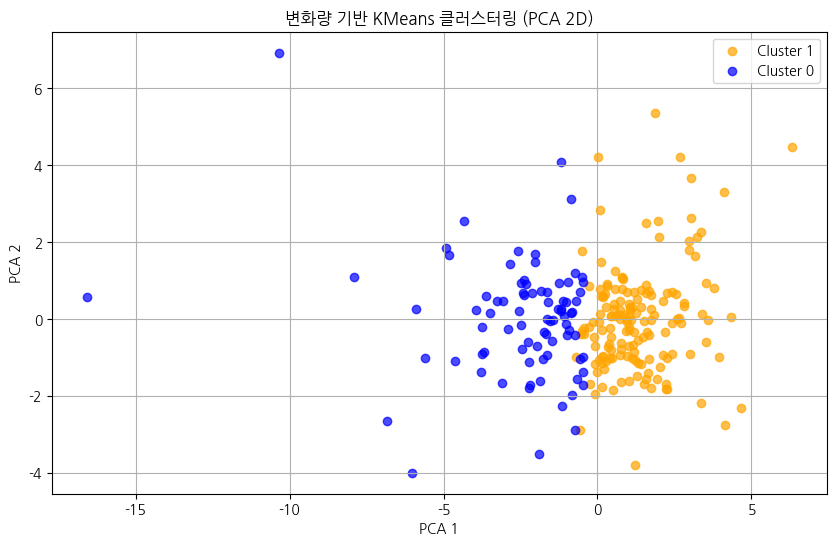

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# 시각화
plt.figure(figsize=(10, 6))

colors = {0: 'blue', 1: 'orange'}
for cluster_label in df_plot['Cluster'].unique():
    subset = df_plot[df_plot['Cluster'] == cluster_label]
    plt.scatter(subset['PCA1'], subset['PCA2'],
                label=f'Cluster {cluster_label}', alpha=0.7, c=colors[cluster_label])

plt.title('변화량 기반 KMeans 클러스터링 (PCA 2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()

- 0 : 위기상황 ( 넓게 퍼진 변화량 큰 집단 : 변동성이 큼)
- 1 : 평시

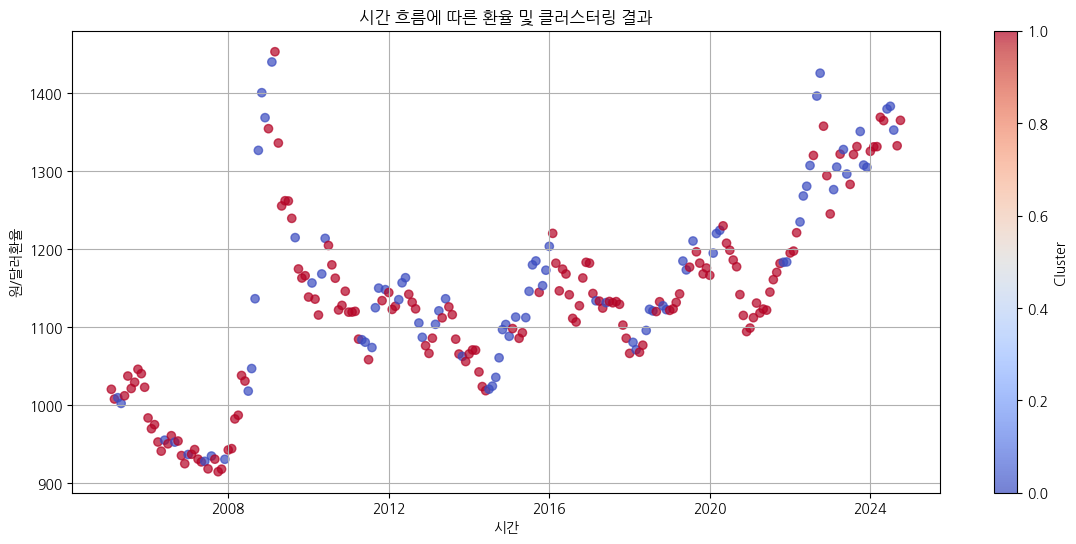

In [ ]:
import matplotlib.pyplot as plt

# TIME 컬럼이 datetime이 아니면 먼저 변환
df_diff['TIME'] = pd.to_datetime(df_diff['TIME'])

# TIME 기준으로 정렬
df_diff = df_diff.sort_values('TIME')

# 시계열 그래프 그리기
plt.figure(figsize=(14,6))
plt.scatter(df_diff['TIME'], df_diff['원/달러환율'], c=df_diff['Cluster'], cmap='coolwarm', alpha=0.7)
plt.title('시간 흐름에 따른 환율 및 클러스터링 결과')
plt.xlabel('시간')
plt.ylabel('원/달러환율')
plt.grid(True)
plt.colorbar(label='Cluster')
plt.show()


2008 금융위기, 2022 자이언트스텝 급등기에 Cluster 0이 등장

완벽하지는 않지만, 변화량 중심으로 위기를 포착하는데 어느 정도 성공

Cluster 0은 전체적으로 변화량이 크고 불안정한 패턴을 가진 구간이며, 실제 금융위기/자이언트스텝 환율 급등 구간과 부분적으로 맞물림.

-> 변화량(diff) 중심 클러스터링이 위기 감지에 조금 더 적합

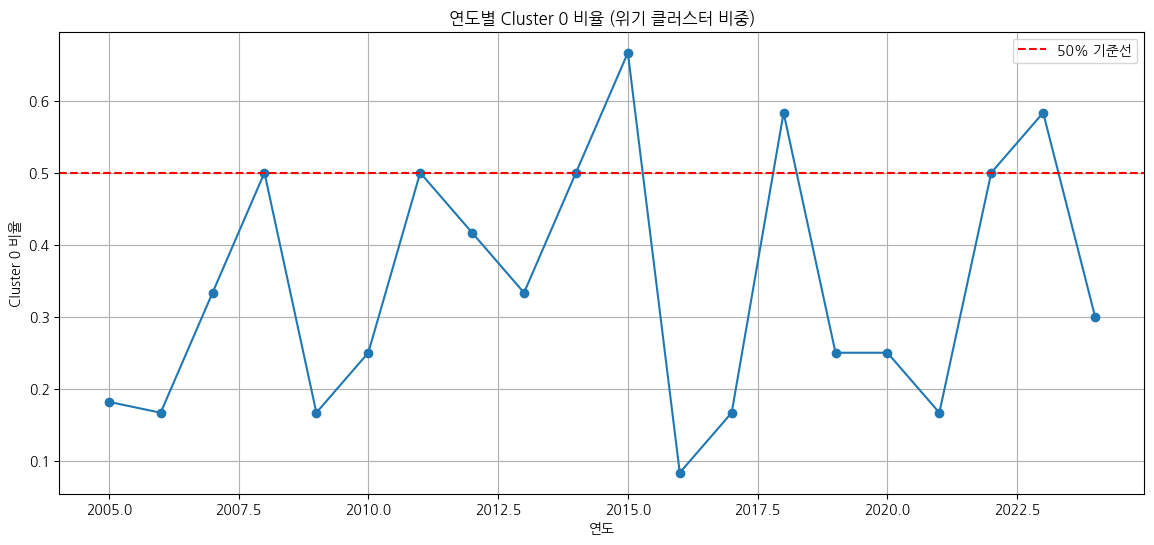

In [ ]:
import matplotlib.pyplot as plt

# 1. 연도 컬럼 추가
df_diff['연도'] = pd.to_datetime(df_diff['TIME']).dt.year

# 2. 연도별 Cluster 0 비율 계산
cluster0_counts = df_diff.groupby('연도')['Cluster'].apply(lambda x: (x==0).sum())
total_counts = df_diff.groupby('연도')['Cluster'].count()
cluster0_ratio = cluster0_counts / total_counts

# 3. 시각화
plt.figure(figsize=(14,6))
plt.plot(cluster0_ratio.index, cluster0_ratio.values, marker='o')
plt.axhline(0.5, color='red', linestyle='--', label='50% 기준선')
plt.title('연도별 Cluster 0 비율 (위기 클러스터 비중)')
plt.xlabel('연도')
plt.ylabel('Cluster 0 비율')
plt.legend()
plt.grid(True)
plt.show()


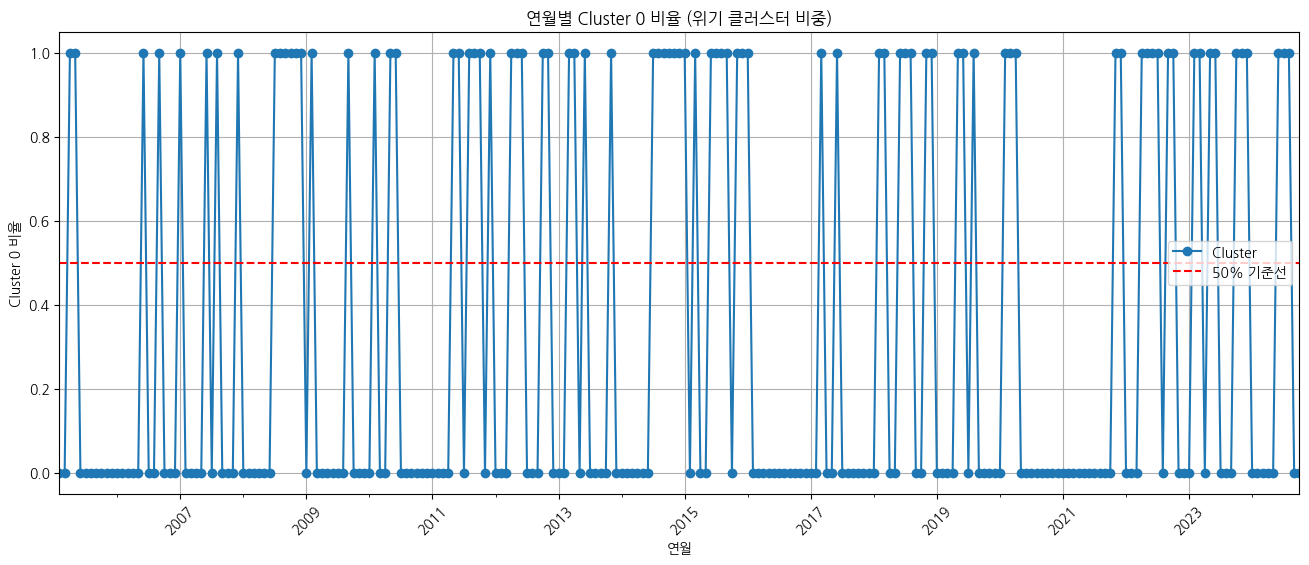

In [ ]:
# 1. 연월 컬럼 추가
df_diff['연월'] = pd.to_datetime(df_diff['TIME']).dt.to_period('M')

# 2. 연월별 Cluster 0 비율 계산
cluster0_counts_month = df_diff.groupby('연월')['Cluster'].apply(lambda x: (x==0).sum())
total_counts_month = df_diff.groupby('연월')['Cluster'].count()
cluster0_ratio_month = cluster0_counts_month / total_counts_month

# 3. 시각화
plt.figure(figsize=(16,6))
cluster0_ratio_month.plot(marker='o')
plt.axhline(0.5, color='red', linestyle='--', label='50% 기준선')
plt.title('연월별 Cluster 0 비율 (위기 클러스터 비중)')
plt.xlabel('연월')
plt.ylabel('Cluster 0 비율')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

### HDBSCAN

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



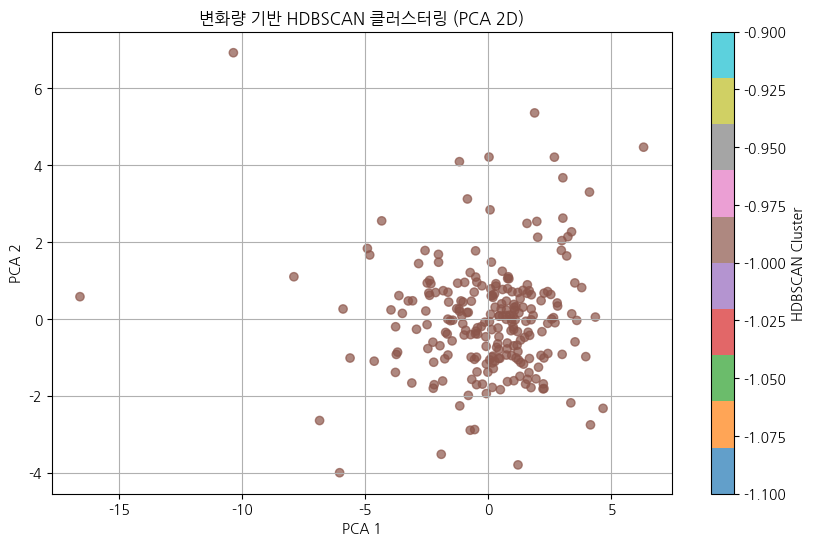

In [ ]:
# 라이브러리 설치 (필요시)
# !pip install hdbscan

import hdbscan
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. HDBSCAN 모델 생성 및 학습
hdb = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5)
hdb_clusters = hdb.fit_predict(X_scaled)

# 2. 결과 DataFrame에 저장
df_diff['HDBSCAN_Cluster'] = hdb_clusters

# 3. PCA로 2D 시각화
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_plot = df_diff.copy()
df_plot['PCA1'] = X_pca[:, 0]
df_plot['PCA2'] = X_pca[:, 1]

# 4. 시각화
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_plot['PCA1'], df_plot['PCA2'], c=df_plot['HDBSCAN_Cluster'], cmap='tab10', alpha=0.7)
plt.title('변화량 기반 HDBSCAN 클러스터링 (PCA 2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='HDBSCAN Cluster')
plt.grid(True)
plt.show()
